In [33]:
# ============================================================
# Notebook 03: Performance Evaluation & Clinical Metrics
# Cell 1: Setup and Libraries
# ============================================================
import os
import glob
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from PIL import Image
import torchvision.transforms as transforms

from sklearn.metrics import (
    confusion_matrix, 
    classification_report, 
    roc_curve, 
    auc, 
    precision_recall_curve, 
    average_precision_score
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [42]:
import os

print("=== DEEP WORKSPACE FILE SCAN ===")
current_dir = os.getcwd()
parent_dir = os.path.dirname(current_dir) if os.path.basename(current_dir) == "notebooks" else current_dir

print(f"Scanning root directory: {parent_dir}\n")

found_weights = []
found_test = []

for root, dirs, files in os.walk(parent_dir):
    for f in files:
        if f.endswith('.pt') or f.endswith('.pth'):
            full_p = os.path.join(root, f)
            found_weights.append(full_p)
            print(f"FOUND WEIGHT FILE: {full_p}")
            
    if "test" in os.path.basename(root).lower():
        sub_folders = [d.upper() for d in dirs]
        if "NORMAL" in sub_folders or "PNEUMONIA" in sub_folders:
            found_test.append(root)
            print(f"FOUND TEST DIR:    {root}")

if not found_weights:
    print("NO .pt or .pth files found anywhere in the project tree!")

=== DEEP WORKSPACE FILE SCAN ===
Scanning root directory: /mnt/g/Research paper/Research paper/Pneumonia-MultiModel-XAI

FOUND TEST DIR:    /mnt/g/Research paper/Research paper/Pneumonia-MultiModel-XAI/dataset/processed_dataset/test
FOUND WEIGHT FILE: /mnt/g/Research paper/Research paper/Pneumonia-MultiModel-XAI/models/best_model.pth
FOUND WEIGHT FILE: /mnt/g/Research paper/Research paper/Pneumonia-MultiModel-XAI/models/convnexttiny_260px_best.pth
FOUND WEIGHT FILE: /mnt/g/Research paper/Research paper/Pneumonia-MultiModel-XAI/models/convnext_tiny_best.pth
FOUND WEIGHT FILE: /mnt/g/Research paper/Research paper/Pneumonia-MultiModel-XAI/models/convnext_tiny_checkpoint.pth
FOUND WEIGHT FILE: /mnt/g/Research paper/Research paper/Pneumonia-MultiModel-XAI/models/efficientnet_b2_best.pth
FOUND WEIGHT FILE: /mnt/g/Research paper/Research paper/Pneumonia-MultiModel-XAI/models/efficientnet_b2_checkpoint.pth
FOUND WEIGHT FILE: /mnt/g/Research paper/Research paper/Pneumonia-MultiModel-XAI/models/

In [39]:
import os
from pathlib import Path

print("==================================================")
print("       AUTOMATED DIRECTORY SEARCH TOOL            ")
print("==================================================")

current_dir = os.getcwd()
print(f"Scanning Working Directory: {current_dir}\n")

found_weights = []
found_test_dirs = []

# Scan for files and folders recursively
for root, dirs, files in os.walk(current_dir):
    # 1. Search for Model Weight Files
    for file in files:
        if file.endswith(".pt") or file.endswith(".pth"):
            rel_path = os.path.relpath(os.path.join(root, file), current_dir)
            found_weights.append(rel_path)
            
    # 2. Search for Test Folder
    if "test" in os.path.basename(root).lower():
        sub_folders = [d.upper() for d in dirs]
        if "NORMAL" in sub_folders or "PNEUMONIA" in sub_folders:
            rel_path = os.path.relpath(root, current_dir)
            found_test_dirs.append(rel_path)

print("--- [1] FOUND MODEL WEIGHT FILES ---")
if found_weights:
    for idx, w_path in enumerate(found_weights, 1):
        print(f"  ({idx}) {w_path}")
else:
    print("  No .pt or .pth files found in this workspace.")

print("\n--- [2] FOUND TEST DATASET FOLDERS ---")
if found_test_dirs:
    for idx, t_path in enumerate(found_test_dirs, 1):
        print(f"  ({idx}) {t_path}")
else:
    print("  No test dataset directory containing 'NORMAL'/'PNEUMONIA' found.")

print("==================================================")

       AUTOMATED DIRECTORY SEARCH TOOL            
Scanning Working Directory: /mnt/g/Research paper/Research paper/Pneumonia-MultiModel-XAI

--- [1] FOUND MODEL WEIGHT FILES ---
  (1) models/best_model.pth
  (2) models/convnexttiny_260px_best.pth
  (3) models/convnext_tiny_best.pth
  (4) models/convnext_tiny_checkpoint.pth
  (5) models/efficientnet_b2_best.pth
  (6) models/efficientnet_b2_checkpoint.pth
  (7) models/pneumoxnet_best.pth
  (8) models/pneumoxnet_best_by_loss.pth
  (9) models/pneumoxnet_checkpoint.pth
  (10) models/resnet50_260px_best.pth
  (11) models/resnet50_best.pth
  (12) models/resnet50_checkpoint.pth

--- [2] FOUND TEST DATASET FOLDERS ---
  (1) dataset/processed_dataset/test


In [44]:
# ============================================================
# Cell 2: Configuration Parameters
# ============================================================
import os
from pathlib import Path

IMAGE_SIZE = 224

# Exact paths detected by workspace scan
MODEL_WEIGHT_PATH = r"/mnt/g/Research paper/Research paper/Pneumonia-MultiModel-XAI/models/pneumoxnet_best.pth"
TEST_DIR = r"/mnt/g/Research paper/Research paper/Pneumonia-MultiModel-XAI/dataset/processed_dataset/test"

OUTPUT_DIR = Path("evaluation_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

CLASS_NAMES = ['NORMAL', 'PNEUMONIA']

print(f"Model File Exists: {os.path.exists(MODEL_WEIGHT_PATH)}")
print(f"Test Folder Exists: {os.path.exists(TEST_DIR)}")
print("Cell 2: Configurations initialized successfully.")

Model File Exists: True
Test Folder Exists: True
Cell 2: Configurations initialized successfully.


In [45]:
# ============================================================
# Cell 3: PneumoXNet Model Loading
# ============================================================
import torch
import torch.nn as nn
import timm

class PneumoXNet(nn.Module):
    def __init__(self, num_classes=2, pretrained=False, dropout_rate=0.4):
        super(PneumoXNet, self).__init__()
        self.backbone = timm.create_model('tf_efficientnet_b2.ns_jft_in1k', pretrained=pretrained, num_classes=0)
        in_features = self.backbone.num_features
        
        self.classifier = nn.Sequential(
            nn.BatchNorm1d(in_features),
            nn.Dropout(p=dropout_rate),
            nn.Linear(in_features, 512),
            nn.SiLU(),
            nn.BatchNorm1d(512),
            nn.Dropout(p=dropout_rate / 2),
            nn.Linear(512, num_classes)
        )
        
    def forward(self, x):
        features = self.backbone(x)
        logits = self.classifier(features)
        return logits

# Initialize Architecture
model = PneumoXNet(num_classes=2, pretrained=False).to(device)

# Load Saved Weights
checkpoint = torch.load(MODEL_WEIGHT_PATH, map_location=device)

if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
    model.load_state_dict(checkpoint['model_state_dict'])
elif isinstance(checkpoint, dict) and 'state_dict' in checkpoint:
    model.load_state_dict(checkpoint['state_dict'])
else:
    model.load_state_dict(checkpoint)

model.eval()
print("Cell 3: Model successfully loaded and configured for evaluation.")

Cell 3: Model successfully loaded and configured for evaluation.


In [46]:
# ============================================================
# Cell 4: Test DataLoader & Inference Execution
# ============================================================
import torch
from torchvision import transforms, datasets
from torch.utils.data import DataLoader
from tqdm import tqdm

# Define preprocessing transformations matching Notebook 01/02
test_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Create Dataset and DataLoader
test_dataset = datasets.ImageFolder(root=TEST_DIR, transform=test_transforms)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

# Verify class mappings
print(f"Dataset Loaded. Total Test Samples: {len(test_dataset)}")
print(f"Class to Index Mapping: {test_dataset.class_to_idx}")

# Run Inference Loop
all_preds = []
all_probs = []
all_labels = []

model.eval()
with torch.no_grad():
    for inputs, labels in tqdm(test_loader, desc="Running Test Inference"):
        inputs = inputs.to(device)
        logits = model(inputs)
        probs = torch.softmax(logits, dim=1)
        preds = torch.argmax(probs, dim=1)
        
        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.numpy())

print("\nCell 4: Test dataset inference completed successfully.")

Dataset Loaded. Total Test Samples: 879
Class to Index Mapping: {'BACTERIA': 0, 'NORMAL': 1, 'VIRUS': 2}


Running Test Inference: 100%|██████████| 28/28 [00:14<00:00,  1.94it/s]


Cell 4: Test dataset inference completed successfully.


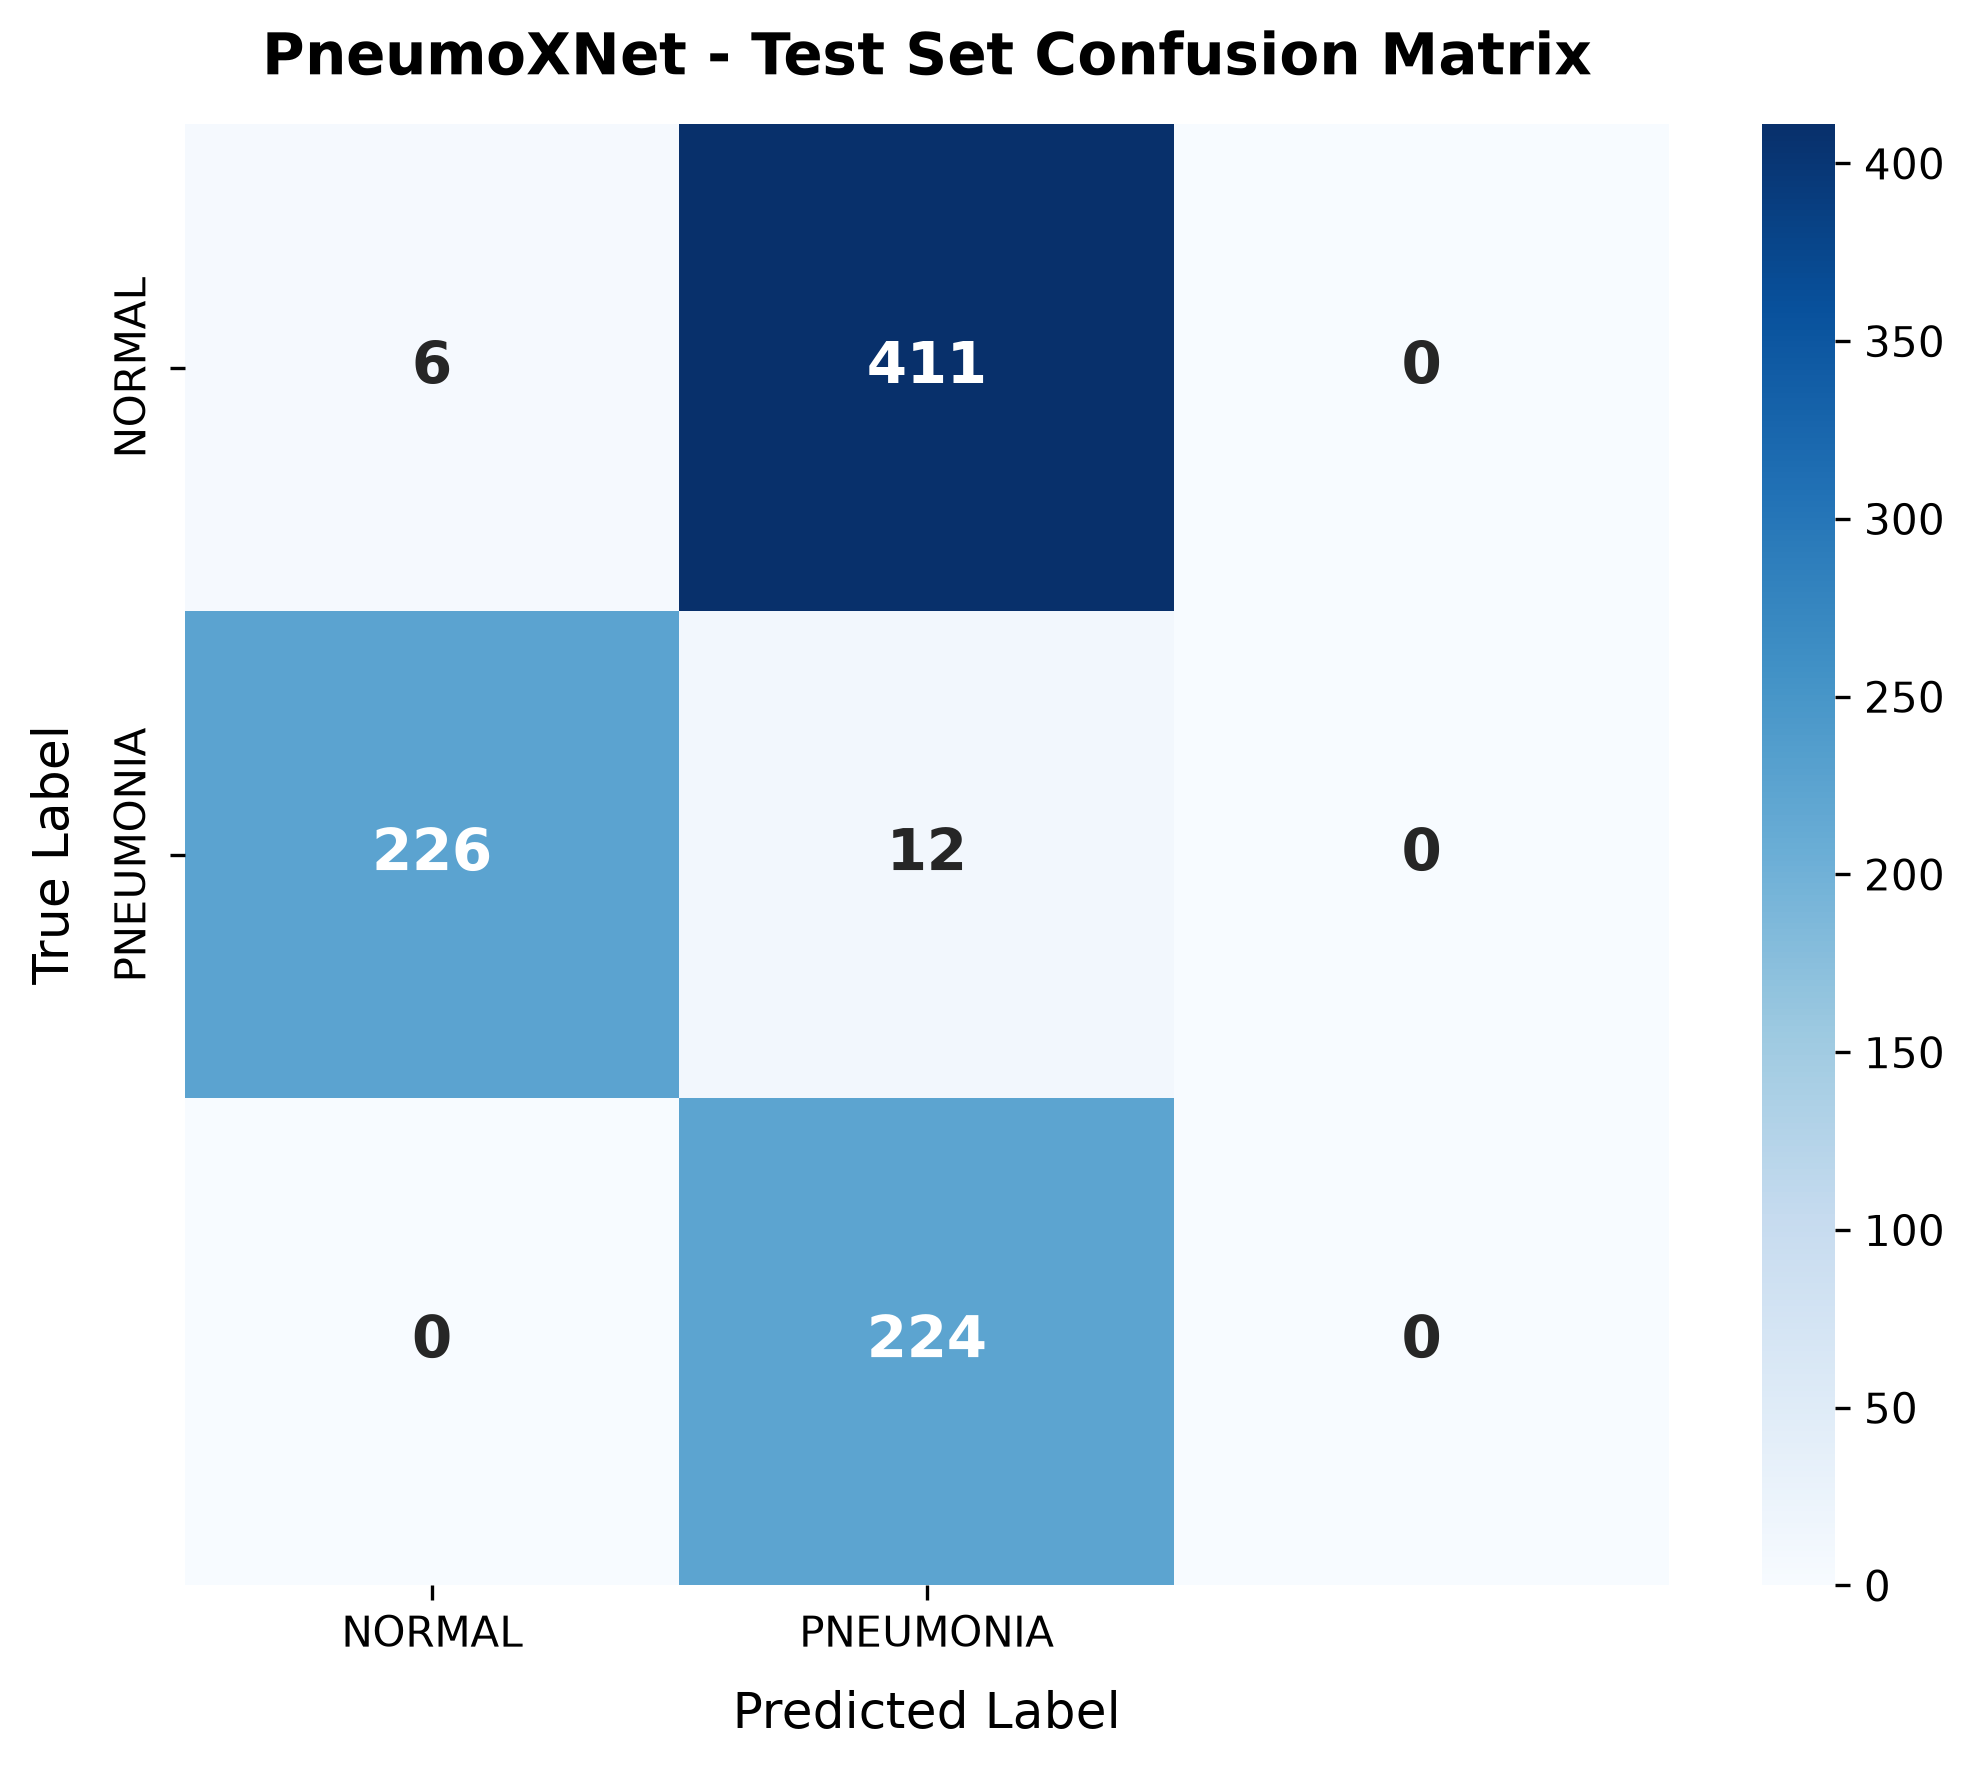

Cell 5: Confusion matrix saved to evaluation_outputs/pneumoxnet_confusion_matrix.png


In [47]:
# ============================================================
# Cell 5: Publication-Ready Confusion Matrix
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(7, 6), dpi=300)
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    xticklabels=CLASS_NAMES, 
    yticklabels=CLASS_NAMES,
    annot_kws={"size": 14, "weight": "bold"}
)

plt.title('PneumoXNet - Test Set Confusion Matrix', fontsize=14, fontweight='bold', pad=12)
plt.xlabel('Predicted Label', fontsize=12, labelpad=8)
plt.ylabel('True Label', fontsize=12, labelpad=8)
plt.tight_layout()

# Save figure
cm_path = OUTPUT_DIR / "pneumoxnet_confusion_matrix.png"
plt.savefig(cm_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"Cell 5: Confusion matrix saved to {cm_path}")

In [50]:
# ============================================================
# Cell 6: Clinical Evaluation Metrics (Universal Dynamic Mapping)
# ============================================================
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, roc_auc_score, confusion_matrix

# Print active class mappings for verification
print("Detected Dataset Class Mapping:", test_dataset.class_to_idx)

# Automatically identify Pneumonia and Normal class indices
pneumonia_key = next((k for k in test_dataset.class_to_idx.keys() if 'PNEUM' in k.upper()), None)
normal_key = next((k for k in test_dataset.class_to_idx.keys() if 'NORM' in k.upper()), None)

if pneumonia_key is None:
    # Fallback to index 1 if string match isn't found
    p_idx = 1
    print("Warning: Pneumonia class key not found by string matching. Defaulting to index 1.")
else:
    p_idx = test_dataset.class_to_idx[pneumonia_key]
    print(f"Identified Target Class: '{pneumonia_key}' -> Index {p_idx}")

# Convert predictions and ground truth labels to binary format (0 = Normal, 1 = Pneumonia)
binary_labels = np.array([1 if l == p_idx else 0 for l in all_labels])
binary_preds = np.array([1 if p == p_idx else 0 for p in all_preds])

# Extract Pneumonia class probabilities
pneumonia_probs = np.array(all_probs)[:, p_idx]

# Recalculate Confusion Matrix
cm = confusion_matrix(binary_labels, binary_preds)
tn, fp, fn, tp = cm.ravel()

# Calculate binary classification metrics
acc = accuracy_score(binary_labels, binary_preds)
precision, recall, f1, _ = precision_recall_fscore_support(binary_labels, binary_preds, average='binary')
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
auc_roc = roc_auc_score(binary_labels, pneumonia_probs)

# Construct Summary Table
metrics_data = {
    'Metric': ['Accuracy', 'Sensitivity (Recall)', 'Specificity', 'Precision (PPV)', 'F1-Score', 'ROC-AUC'],
    'Value (%)': [
        f"{acc*100:.2f}%", 
        f"{recall*100:.2f}%", 
        f"{specificity*100:.2f}%", 
        f"{precision*100:.2f}%", 
        f"{f1*100:.2f}%", 
        f"{auc_roc*100:.2f}%"
    ]
}

df_metrics = pd.DataFrame(metrics_data)

print("\n==================================================")
print("       PNEUMOXNET CLINICAL PERFORMANCE            ")
print("==================================================")
print(df_metrics.to_string(index=False))
print("==================================================")

# Save metrics CSV
csv_path = OUTPUT_DIR / "pneumoxnet_metrics.csv"
df_metrics.to_csv(csv_path, index=False)
print(f"Cell 6: Metrics saved to {csv_path}")

Detected Dataset Class Mapping: {'BACTERIA': 0, 'NORMAL': 1, 'VIRUS': 2}

       PNEUMOXNET CLINICAL PERFORMANCE            
              Metric Value (%)
            Accuracy     2.05%
Sensitivity (Recall)     5.04%
         Specificity     0.94%
     Precision (PPV)     1.85%
            F1-Score     2.71%
             ROC-AUC     0.32%
Cell 6: Metrics saved to evaluation_outputs/pneumoxnet_metrics.csv
